# MARS DAS：单一主导模态 Scholte 波三台干涉去噪

## 1. 案例目标

分布式声学传感（distributed acoustic sensing，DAS）可以把海底通信光缆转化为超密集地震观测阵列。结合背景噪声互相关，DAS 可用于提取沿水体-沉积物界面传播的 Scholte 波。

传统基于DAS的高频面波成像方法普遍采用子阵列叠加方法提取频散，子阵列叠加可提高频散能量的稳定性，但其结果代表子阵列范围内的平均响应，可能平滑小尺度横向结构。TSI 直接作用于通道对尺度，有机会在增强直达 Scholte 波的同时保留 DAS 的密集空间采样。

MARS DAS 记录为沿光缆方向的单分量应变或应变率响应，无法利用径向-垂向质点运动进行极化分离，同时该 DAS 阵列上的面波模态变化复杂，难以可靠给定模式标签，因此，本教程不尝试在全光缆范围内分离多模态 Scholte 波，而是选取一段第一高阶 Scholte 波区段（5-6.9 km; 通道250-345）开展去噪作为演示。

## 2. 研究区与数据

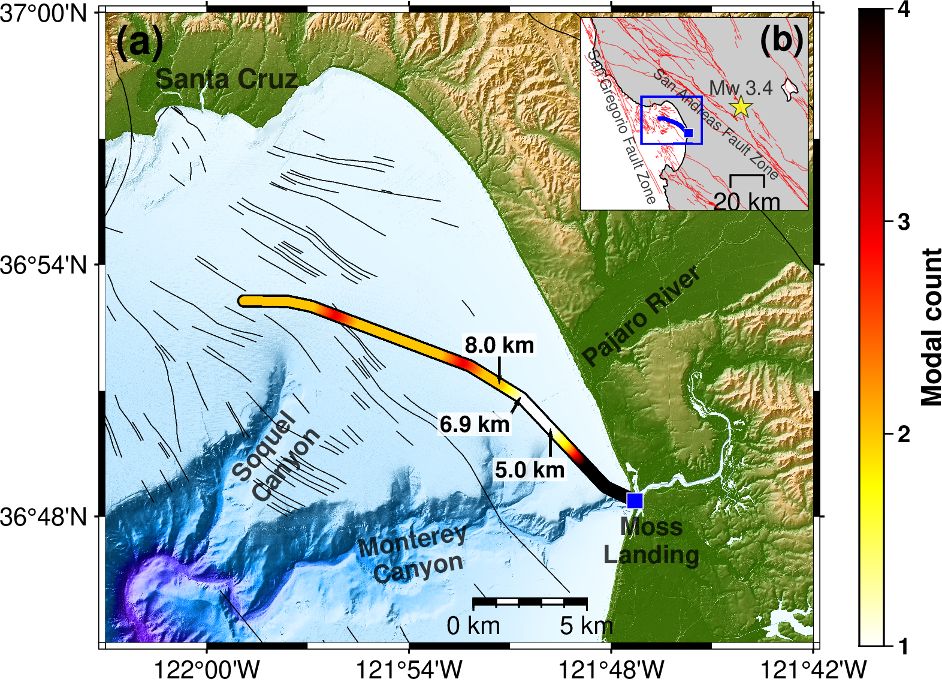
Monterey Accelerated Research System（MARS）海底光缆位于美国加利福尼亚州 Monterey Bay 大陆架。相关 DAS 观测具有以下特征：

- 背景噪声连续记录时间为 2018 年 3 月 10-13 日；
- 光缆总长度约 20 km；
- DAS 标距为 10 m；
- 原始通道间距约 2 m；
- 本教程使用的 ANC 已重采样至 20 m 通道间距；
- ANC 分析频带覆盖 0.5-8 Hz，本教程在去噪中使用 0.5-4 Hz。

论文首先使用滑动子阵列 MASW 和双聚束分析研究 Scholte 波模态的空间变化。结果表明，5-8 km 区段主要由一条连续的第一高阶 Scholte 波能量带占优，较弱的基阶能量只在部分通道对出现。

由于光缆在约 6.9 km 处发生弯折，为更好满足 TSI 的一维线性传播假设，本教程使用以下子阵列：
 5.0-6.9 km | 250-345 

## 3. Step 0：导入程序并设置参数

In [ ]:

from pathlib import Path

import matplotlib.pyplot as plt

import numpy as np
from tsi_denoising import (
    Wavefield,
    MASW,
    DenoisingResult,
    read_sac_directory,
    denoise_station_pair_demo,
    denoise_wavefield_iteratively,
    plot_denoised_result,
)

CASE_DIR = Path("./")
SAC_DIR = CASE_DIR / "input"
PROCESSED_DIR = CASE_DIR / "processed"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

if not SAC_DIR.is_dir():
    raise FileNotFoundError(
        f"输入数据目录不存在：{SAC_DIR.resolve()}\n"
        "请先在项目根目录运行 `python retrieve_datasets.py` 下载教学数据。"
    )

print(f"输入数据目录：{SAC_DIR.resolve()}")
print(f"缓存目录：{PROCESSED_DIR.resolve()}")

COMPONENTS = ("RR",)
FMIN = 0.5; FMAX = 3.5 # Frequency bounds
VMIN = 0.1; VMAX = 2. # Moveout velocity bounds
EXAMPLE_PAIR = ("270", "325") # Example station pair for denoising demonstration
EXAMPLE_PERIODS = (1.6, 0.4) # Example periods for denoising demonstration

输入数据目录：/Users/yusong/projects/TSI-Denoising/tutorial/MARS_DAS/input
缓存目录：/Users/yusong/projects/TSI-Denoising/tutorial/MARS_DAS/processed


## 4. Step 1：读取、缓存与预处理波场

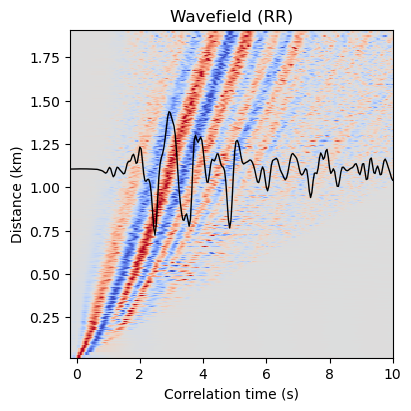

In [12]:
component = COMPONENTS[0]
cache_path = PROCESSED_DIR / f"{component.lower()}_wavefield.npz"
if cache_path.exists():
    wfd_rr = Wavefield.load(cache_path)
else:
    wfd_rr = read_sac_directory(SAC_DIR / component).preprocess()
    wfd_rr.save(cache_path, overwrite=True)


fig, ax = plt.subplots(
    1, 1,
    figsize=(4, 4.),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

wfd_rr.plot(ax=ax, example_pair=EXAMPLE_PAIR, jitter_duplicate_distances=True,tshow_min=-0.2, tshow_max=10.0)
plt.show()


## 5. Step 2：MASW 检查主导 Scholte 波

### 进入 TSI 前的判断

只有当目标波在所选子阵列内具有稳定的稳定单一主导模态时，才进入三台干涉去噪。TSI 的目标是增强相干直达波，而不是替代模态识别。

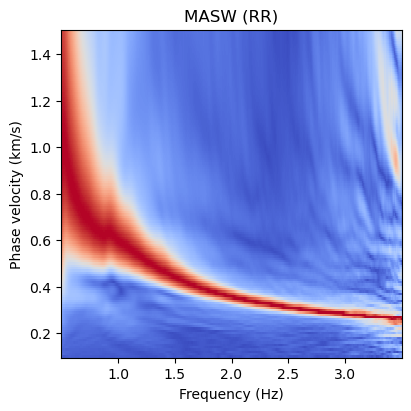

In [13]:
component = COMPONENTS[0]
cache_path = PROCESSED_DIR / f"{component.lower()}_masw.npz"

if cache_path.exists():
    masw_rr = MASW.load(cache_path)
else:
    masw_rr = MASW(wfd_rr,fmin=FMIN,fmax=FMAX,velocities=np.linspace(0.1,1.5,141)).compute(n_jobs=10)
    masw_rr.save(cache_path, overwrite=True)

fig, ax = plt.subplots(
    1, 1,
    figsize=(4, 4.),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

masw_rr.plot(ax=ax)
plt.show()

## 6. Step 3：代表性通道对的 TSI 诊断

(<Figure size 1000x850 with 8 Axes>,
 array([[<Axes: title={'center': 'Virtual shot gather at station 270'}, ylabel='Station number'>,
         <Axes: title={'center': 'Virtual shot gather at station 325'}>,
         <Axes: title={'center': 'Three-station interferometry'}>],
        [<Axes: xlabel='Correlation time (s)', ylabel='Station number'>,
         <Axes: xlabel='Correlation time (s)'>,
         <Axes: xlabel='Correlation time (s)'>]], dtype=object))

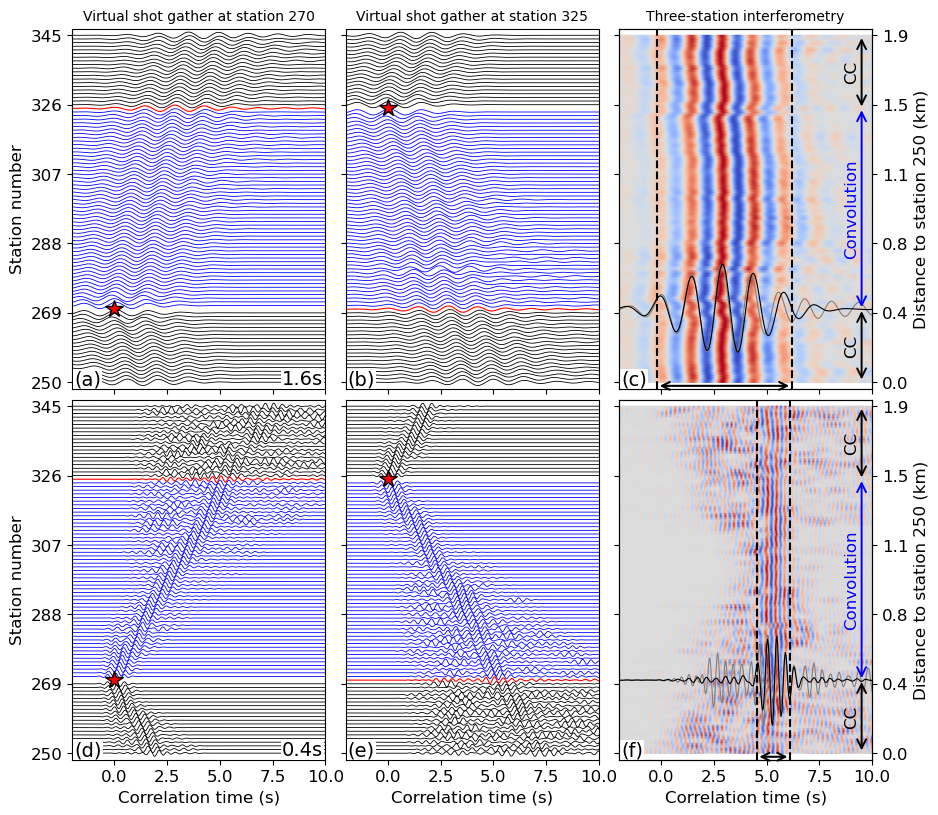

In [14]:
denoise_station_pair_demo(wfd_rr, EXAMPLE_PAIR, periods=EXAMPLE_PERIODS, time_limits= (-2,10))

## 7. Step 4：全波场迭代去噪

Loaded cached denoising result.


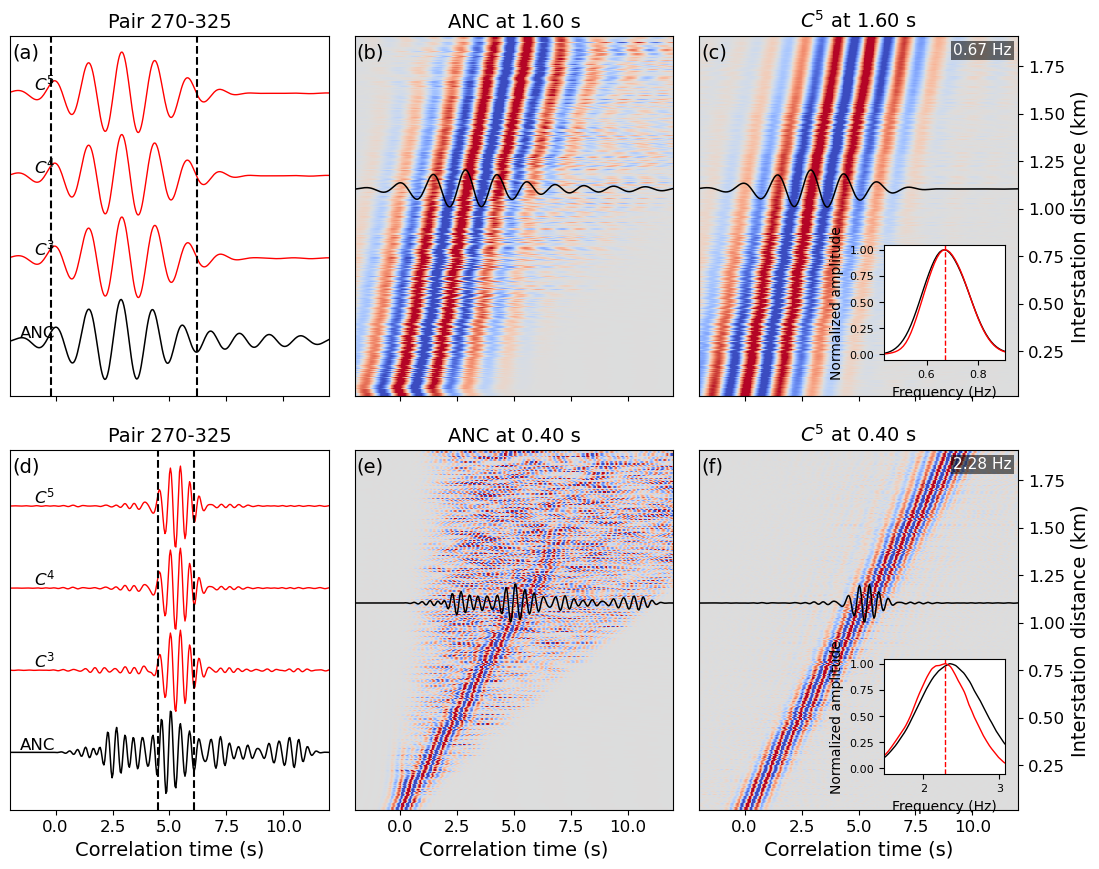

In [ ]:


result_stem = PROCESSED_DIR / "Denoised"
wavefield_file = PROCESSED_DIR / "Denoised_wavefield.npz"
info_file = PROCESSED_DIR / "Denoised_info.npz"

if wavefield_file.exists() and info_file.exists():
    denoised_result = DenoisingResult.load(result_stem)
    print("Loaded cached denoising result.")
else:
    denoised_result = denoise_wavefield_iteratively(
        wfd_rr,
        EXAMPLE_PAIR,
        threshold=0.05,
        first_iteration_convolution=True,
        max_iterations=4,
        taper_output=False,
        n_jobs=10,
    )
    denoised_result.save(
        result_stem,
        overwrite=wavefield_file.exists() or info_file.exists(),
    )
    print("Computed and saved denoising result.")

plot_denoised_result(wfd_rr, denoised_result, periods=EXAMPLE_PERIODS, time_limits=(-2, 12))
plt.show()

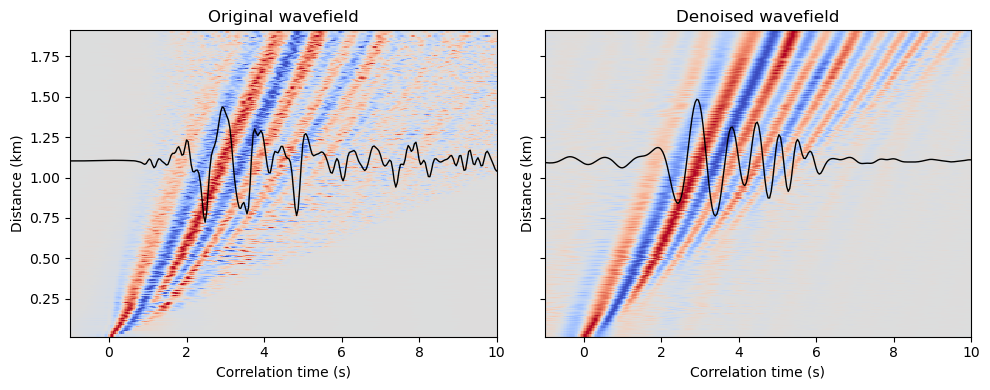

In [16]:
denoised_wavefield=Wavefield.load(PROCESSED_DIR /"Denoised_wavefield.npz")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

wfd_rr.plot(
    ax=axes[0],
    example_pair=EXAMPLE_PAIR,
    tshow_max=10,
    tshow_min=-1,
    jitter_duplicate_distances=True,
)
axes[0].set_title("Original wavefield")

denoised_wavefield.plot(
    ax=axes[1],
    example_pair=EXAMPLE_PAIR,
    tshow_max=10,
    tshow_min=-1,
    jitter_duplicate_distances=True,
)
axes[1].set_title("Denoised wavefield")

plt.tight_layout()
plt.show()